# Stage 4 — Predictive Maintenance brain v2 (AI4I 2020, CORRECT)

**Why this replaces the earlier notebooks:** the synthetic one was degenerate (0 failure windows in test →
NaN AUC); the earlier AI4I one had **data leakage** (random split of overlapping sliding windows — the
notebook's own comment admitted it) plus an invalid 'all 10,000 rows = one machine' framing, so its 0.99
AUC was not real.

AI4I 2020 is a **tabular** dataset: each row is an independent product with sensor readings + a failure
label. So we train a clean **tabular classifier** — no windowing, **stratified split (no leakage)**, and we
**drop the leaky columns** `TWF/HDF/PWF/OSF/RNF` (they literally compose the `Machine failure` target).

**Run:** `Runtime ▸ Change runtime type ▸ GPU` → `Runtime ▸ Run all`. Last cell downloads `pdm_brain.zip`
— send it back. No API key needed. **Honest expectation:** ROC-AUC ~0.93–0.98 and a *lower* PR-AUC (the
data is ~3.4% failures) — that imbalance gap is correct, not a bug.

In [1]:
import platform, torch, numpy as np, pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             roc_curve, precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('torch',torch.__version__,'| device',DEVICE)
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

torch 2.11.0+cu128 | device cuda


## 1. Download AI4I 2020 (UCI, CC BY 4.0)

In [2]:
import requests, zipfile, io
url='https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
z=zipfile.ZipFile(io.BytesIO(requests.get(url).content))
raw=pd.read_csv(z.open('ai4i2020.csv'))
print(raw.shape); print('columns:', raw.columns.tolist())
print('failure rate:', round(raw['Machine failure'].mean(),4), '(real AI4I is ~3.4% — imbalanced)')
raw.head()

(10000, 14)
columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure rate: 0.0339 (real AI4I is ~3.4% — imbalanced)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Features + target (DROP leaky columns)
Drop `UDI`, `Product ID` (identifiers) and `TWF/HDF/PWF/OSF/RNF` (the failure-mode flags that *are* the
target — keeping them is leakage). Encode `Type` (L/M/H → 0/1/2). Add two physical features:
`temp_diff = Process−Air` and `power = Torque·ω`.

In [3]:
df=raw.copy()
df['Type_ord']=df['Type'].map({'L':0,'M':1,'H':2}).astype('float32')
df['temp_diff']=df['Process temperature [K]']-df['Air temperature [K]']
df['power_w']=df['Torque [Nm]']*df['Rotational speed [rpm]']*2*np.pi/60.0
FEATURES=['Type_ord','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
          'Torque [Nm]','Tool wear [min]','temp_diff','power_w']
LEAKY=['TWF','HDF','PWF','OSF','RNF']  # these compose the target -> dropped
X=df[FEATURES].values.astype('float32')
y=df['Machine failure'].values.astype('float32')
print('X',X.shape,'| positives',int(y.sum()),'(',round(float(y.mean()),4),')','| dropped leaky:',LEAKY)

X (10000, 8) | positives 339 ( 0.0339 ) | dropped leaky: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 3. Stratified split (no leakage — rows are independent) + scale on train only

In [4]:
Xtr,Xtmp,ytr,ytmp=train_test_split(X,y,test_size=0.30,stratify=y,random_state=SEED)
Xva,Xte,yva,yte=train_test_split(Xtmp,ytmp,test_size=0.50,stratify=ytmp,random_state=SEED)
scaler=StandardScaler().fit(Xtr)
Xtr,Xva,Xte=scaler.transform(Xtr).astype('float32'),scaler.transform(Xva).astype('float32'),scaler.transform(Xte).astype('float32')
print('train/val/test',Xtr.shape,Xva.shape,Xte.shape)
print('pos rate  train/val/test:',round(ytr.mean(),4),round(yva.mean(),4),round(yte.mean(),4),'(all ~equal = clean stratify)')

train/val/test (7000, 8) (1500, 8) (1500, 8)
pos rate  train/val/test: 0.0339 0.034 0.034 (all ~equal = clean stratify)


## 4. Tabular MLP

In [5]:
class FailureMLP(nn.Module):
    def __init__(self,d,h1=64,h2=32,dropout=0.3):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,h1),nn.ReLU(),nn.Dropout(dropout),
                               nn.Linear(h1,h2),nn.ReLU(),nn.Dropout(dropout),nn.Linear(h2,1))
    def forward(self,x): return self.net(x).squeeze(-1)
CFG=dict(arch='MLP',input_dim=len(FEATURES),h1=64,h2=32,dropout=0.3,features=FEATURES,
         type_encoding={'L':0,'M':1,'H':2},task='per-snapshot failure-risk (tabular)')
model=FailureMLP(CFG['input_dim'],CFG['h1'],CFG['h2'],CFG['dropout']).to(DEVICE)
print(model)

FailureMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Train (GPU; pos_weight for the ~3.4% imbalance; early-stop on val PR-AUC)

early stop @ 101


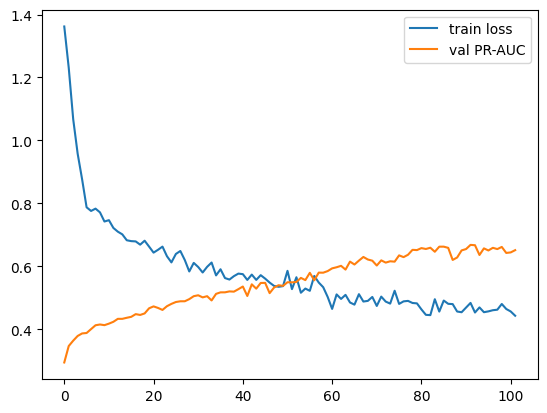

In [6]:
def dl(Xa,ya,bs=256,sh=False): return DataLoader(TensorDataset(torch.tensor(Xa),torch.tensor(ya)),batch_size=bs,shuffle=sh)
tr,va=dl(Xtr,ytr,sh=True),dl(Xva,yva)
posw=torch.tensor([(len(ytr)-ytr.sum())/max(ytr.sum(),1)],device=DEVICE)
crit=nn.BCEWithLogitsLoss(pos_weight=posw); opt=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-5)
def predict(dloader):
    model.eval(); P=[];T=[]
    with torch.no_grad():
        for xb,yb in dloader: P.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy()); T.append(yb.numpy())
    return np.concatenate(P),np.concatenate(T)
best,best_state,bad,PAT=-1,None,0,10; hist=[]
for ep in range(120):
    model.train(); tot=0
    for xb,yb in tr:
        opt.zero_grad(); loss=crit(model(xb.to(DEVICE)),yb.to(DEVICE)); loss.backward(); opt.step(); tot+=loss.item()*len(xb)
    pv,tv=predict(va); vap=average_precision_score(tv,pv); hist.append((tot/len(Xtr),vap))
    if vap>best: best,best_state,bad=vap,{k:v.cpu().clone() for k,v in model.state_dict().items()},0
    else:
        bad+=1
        if bad>=PAT: print('early stop @',ep); break
model.load_state_dict(best_state)
plt.plot([h[0] for h in hist],label='train loss'); plt.plot([h[1] for h in hist],label='val PR-AUC'); plt.legend(); plt.show()

## 6. Honest evaluation on the held-out test set

TEST  ROC-AUC 0.972 | PR-AUC 0.679 | baseline PR-AUC(=pos rate) 0.034 | thr 0.934
              precision    recall  f1-score   support

         0.0      0.986     0.986     0.986      1449
         1.0      0.608     0.608     0.608        51

    accuracy                          0.973      1500
   macro avg      0.797     0.797     0.797      1500
weighted avg      0.973     0.973     0.973      1500

confusion matrix [[TN,FP],[FN,TP]]:
 [[1429   20]
 [  20   31]]


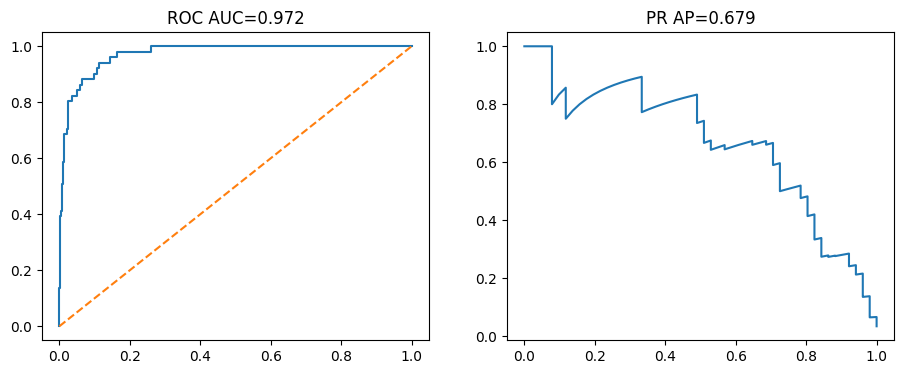

In [7]:
pte,tte=predict(dl(Xte,yte))
roc=roc_auc_score(tte,pte); prauc=average_precision_score(tte,pte)
pva,tva=predict(va)
prec,rec,thr=precision_recall_curve(tva,pva); f1=2*prec*rec/(prec+rec+1e-9)
THRESH=float(thr[max(0,f1[:-1].argmax())])
pred=(pte>=THRESH).astype(int)
print(f'TEST  ROC-AUC {roc:.3f} | PR-AUC {prauc:.3f} | baseline PR-AUC(=pos rate) {tte.mean():.3f} | thr {THRESH:.3f}')
print(classification_report(tte,pred,digits=3))
print('confusion matrix [[TN,FP],[FN,TP]]:\n',confusion_matrix(tte,pred))
fpr,tpr,_=roc_curve(tte,pte)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],'--'); ax[0].set_title(f'ROC AUC={roc:.3f}')
ax[1].plot(rec,prec); ax[1].set_title(f'PR AP={prauc:.3f}'); plt.show()

## 7. Export the brain → `pdm_brain.zip` (send this back)

In [8]:
import pickle, json, zipfile, os
os.makedirs('brain',exist_ok=True)
torch.save(model.state_dict(),'brain/pdm_failure_predictor.pt')
pickle.dump(scaler,open('brain/scaler.pkl','wb'))
meta={**CFG,'threshold':THRESH,'seed':SEED,'scaler_mean':scaler.mean_.tolist(),'scaler_scale':scaler.scale_.tolist()}
json.dump(meta,open('brain/model_meta.json','w'),indent=2)
metrics={'roc_auc':round(float(roc),4),'pr_auc':round(float(prauc),4),'threshold':round(THRESH,4),
         'test_positive_rate':round(float(tte.mean()),4),'n_test':int(len(tte)),
         'dataset':'AI4I 2020 (tabular, clean stratified split, leaky cols dropped)','leakage':'none'}
json.dump(metrics,open('brain/metrics.json','w'),indent=2)
with zipfile.ZipFile('pdm_brain.zip','w',zipfile.ZIP_DEFLATED) as z:
    for fn in ['pdm_failure_predictor.pt','scaler.pkl','model_meta.json','metrics.json']: z.write('brain/'+fn,fn)
print(json.dumps(metrics,indent=2))
try:
    from google.colab import files; files.download('pdm_brain.zip')
except Exception as e:
    print('Not in Colab — grab pdm_brain.zip from the file browser.', e)

{
  "roc_auc": 0.9725,
  "pr_auc": 0.6785,
  "threshold": 0.9336,
  "test_positive_rate": 0.034,
  "n_test": 1500,
  "dataset": "AI4I 2020 (tabular, clean stratified split, leaky cols dropped)",
  "leakage": "none"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Sanity checklist (so we trust the number this time)
- `pos rate train/val/test` are ~equal → stratify worked.
- `TWF/HDF/PWF/OSF/RNF` were **dropped** → no target leakage.
- No windowing / no shuffled overlapping windows → no temporal leakage.
- PR-AUC ≫ baseline (pos rate) but **not** ~1.0 → the model has real, honest skill.

If PR-AUC is only marginally above the positive rate, tell me and I'll switch the model to gradient
boosting (XGBoost) — often stronger on tabular data — before we wire the brain in.